# MOFA training different models

We train MOFA on TCGA-BRCA with:
- different K per view (K1 for mRNA, K2 for DNAm, K3 for RPPA),
- feature selection:
  - most variable features per view,
  - ANOVA F-score vs PAM50 per view,
- patient sets:
  - all patients (union of samples across views),
  - intersection patients (present in all three views).

For each configuration we:
1. select K1/K2/K3 features per view,
2. build a MuData object for the chosen patient set,
3. train MOFA with a fixed number of factors,
4. save the model to `exports/mofa_{method}_Kperview_{patients}.hdf5`.


Then we run logerg for different factor configurations.

In the end we check for the most 'informative' features that were forming MOFA factors.

## MOFA training

### Imports and configuration

In [3]:
import os
import pickle

import numpy as np
import pandas as pd

import scanpy as sc
import muon as mu

import matplotlib.pyplot as plt
import seaborn as sns
from helpers import (
    select_top_variable_features_per_view,
    select_top_anova_features_per_view,
)

# ----------------------------------------------------------
# paths and basic config
# ----------------------------------------------------------

DATA_DIR = "../data/TCGA-BRCA/"
EXPORT_DIR = "exports_500"
os.makedirs(EXPORT_DIR, exist_ok=True)

VIEWS = ["mRNA", "DNAm", "RPPA"]

# K1/K2/K3: number of features per view
N_KEEP_PER_VIEW = {
    "mRNA": 500, # K1
    "DNAm": 500, # K2
    "RPPA": 464, # K3 ( keep all proteins)
}

# number of MOFA factors
MOFA_N_FACTORS = 15

# view that carries PAM50 labels for ANOVA, doesnt really matter, they are all the same
LABEL_VIEW = "mRNA"


### Load data and compute patient sets

In [4]:
data = {}
for omic in VIEWS:
    with open(os.path.join(DATA_DIR, f"{omic}.pkl"), "rb") as f:
        data[omic] = pickle.load(f)

for v in VIEWS:
    X = data[v]["expr"]
    print(f"{v}: {X.shape[0]} samples × {X.shape[1]} features")

# patient sets
idx_per_view = {v: set(data[v]["expr"].index) for v in VIEWS}
patients_intersection = sorted(set.intersection(*idx_per_view.values()))
patients_all = sorted(set.union(*idx_per_view.values()))

print(f"Intersection patients: {len(patients_intersection)}")
print(f"All patients (union):  {len(patients_all)}")


C:\Users\Petar\AppData\Local\Temp\ipykernel_43272\2528944166.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data[omic] = pickle.load(f)
C:\Users\Petar\AppData\Local\Temp\ipykernel_43272\2528944166.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access

mRNA: 500 samples × 29995 features
DNAm: 500 samples × 100000 features
RPPA: 500 samples × 464 features
Intersection patients: 401
All patients (union):  658


C:\Users\Petar\AppData\Local\Temp\ipykernel_43272\2528944166.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data[omic] = pickle.load(f)


### MOFA helper: build MuData from filtered views

In [5]:
VIEW_TO_MODKEY = {"mRNA": "rna", "DNAm": "dna", "RPPA": "rppa"}


def build_mdata_from_filtered_views(
    filtered_data: dict,
    full_data: dict,
    views: list[str],
    patient_mode: str = "all",
) -> mu.MuData:
    """
    Construct a MuData object from filtered views.

    patient_mode:
        "all"          -> union of sample IDs across views
        "intersection" -> only samples present in all views
    """
    expr_list = [filtered_data[v]["expr"] for v in views]

    if patient_mode == "all":
        idx = expr_list[0].index
        for X in expr_list[1:]:
            idx = idx.union(X.index)
    elif patient_mode == "intersection":
        idx = expr_list[0].index
        for X in expr_list[1:]:
            idx = idx.intersection(X.index)
    else:
        raise ValueError("patient_mode must be 'all' or 'intersection'")

    idx = idx.sort_values()

    # modalities
    mods = {}
    for v in views:
        df = filtered_data[v]["expr"].reindex(idx)
        mod_key = VIEW_TO_MODKEY.get(v, v.lower())
        mods[mod_key] = sc.AnnData(df)

    mdata = mu.MuData(mods)

    # metadata in obs: concat meta from all views (reindexed)
    meta_frames = []
    for v in views:
        meta = full_data[v].get("meta", None)
        if meta is not None:
            meta_frames.append(meta.reindex(idx))

    if meta_frames:
        meta = pd.concat(meta_frames, axis=1)
        meta = meta.loc[:, ~meta.columns.duplicated()]
        mdata.obs = meta

    return mdata


### Configuration of grid: feature selection & patient modes

In [6]:
SELECTION_METHODS = ["var", "anova"]        # feature ranking
PATIENT_MODES = ["all", "intersection"]     # patient sets


### Main loop: train MOFA for all configurations

In [6]:
for sel in SELECTION_METHODS:
    # ------------------------------------------------------
    # 1) Select K1/K2/K3 features per view
    # ------------------------------------------------------
    if sel == "var":
        print("\n### Feature selection: most variable per view")
        filtered_data, feat_idx = select_top_variable_features_per_view(
            data,
            n_keep_per_view=N_KEEP_PER_VIEW,
            views=VIEWS,
            use="var",    # or "mad" if you want
        )
        method_tag = "var"

    elif sel == "anova":
        print("\n### Feature selection: ANOVA vs PAM50 per view")
        filtered_data, feat_idx = select_top_anova_features_per_view(
            data,
            n_keep_per_view=N_KEEP_PER_VIEW,
            views=VIEWS,
            label_view=LABEL_VIEW,
        )
        method_tag = "anova"

    else:
        raise ValueError(f"Unknown selection method: {sel}")

    # ------------------------------------------------------
    # 2) For this feature set, train MOFA for both patient sets
    # ------------------------------------------------------
    for patient_mode in PATIENT_MODES:
        tag = f"{method_tag}_Kperview_{patient_mode}"
        outfile = os.path.join(EXPORT_DIR, f"mofa_{tag}.hdf5")

        print(f"\n=== Training MOFA: method={method_tag}, patients={patient_mode} ===")

        mdata = build_mdata_from_filtered_views(
            filtered_data=filtered_data,
            full_data=data,
            views=VIEWS,
            patient_mode=patient_mode,
        )

        print("  - Samples in mdata:", mdata.n_obs)
        for mod_key in mdata.mod:
            print(f"    {mod_key}: {mdata[mod_key].X.shape}")

        mu.tl.mofa(
            mdata,
            use_obs="union",          # same as in your existing notebook
            n_factors=MOFA_N_FACTORS,
            convergence_mode="medium",
            outfile=outfile,
        )

        print(f"  --> saved MOFA model to: {outfile}")



### Feature selection: most variable per view
mRNA: kept 500 / 29995 features (most variable, var)
DNAm: kept 500 / 100000 features (most variable, var)
RPPA: kept 464 / 464 features (most variable, var)

=== Training MOFA: method=var, patients=all ===
  - Samples in mdata: 658
    rna: (658, 500)
    dna: (658, 500)
    rppa: (658, 464)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='rna' group='group1' with N=

C:\Users\Petar\anaconda3\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\Petar\anaconda3\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (rna): gaussian
- View 1 (dna): gaussian
- View 2 (rppa): gaussian




######################################
## Training the model with seed 1 ##
######################################



Converged!



#######################
## Training finished ##
#######################


Saving model in exports_500\mofa_var_Kperview_all.hdf5...
Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].
  --> saved MOFA model to: exports_500\mofa_var_Kperview_all.hdf5

=== Training MOFA: method=var, patients=intersection ===
  - Samples in mdata: 401
    rna: (401, 500)
    dna: (401, 500)
    rppa: (401, 464)

        #########################################################
        ###           __  __  ____  ______           

## Logistic regression

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

import mofax as mofa  # already used above, but fine to import again
import matplotlib.pyplot as plt


### Prepare PAM50_any labels

In [8]:
def get_pam50_raw(view_name: str) -> pd.Series:
    meta = data[view_name].get("meta", None)
    if meta is None or "paper_BRCA_Subtype_PAM50" not in meta.columns:
        return pd.Series(index=[], dtype="object")
    s = meta["paper_BRCA_Subtype_PAM50"].astype(str).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    s.name = view_name
    return s

pam_rna_full  = get_pam50_raw("mRNA")
pam_meth_full = get_pam50_raw("DNAm")
pam_prot_full = get_pam50_raw("RPPA")

pam_any = pam_rna_full.copy()
pam_any = pam_any.combine_first(pam_meth_full)
pam_any = pam_any.combine_first(pam_prot_full)
pam_any.name = "PAM50_any"

pam_any.value_counts(dropna=False)


PAM50_any
LumA     352
LumB     138
Basal    119
Her2      49
Name: count, dtype: int64

### Helper to run logistic regression on one MOFA embedding

In [9]:
def run_logreg_on_factors(X_factors: pd.DataFrame,
                          labels_any: pd.Series,
                          title: str,
                          verbose: bool = True):
    """
    X_factors : DataFrame [n_samples x n_factors], index = sample IDs
    labels_any: PAM50_any Series, index = sample IDs
    title     : name used in prints and CM title
    """
    # Align X and y by sample ID and drop missing labels
    y = labels_any.reindex(X_factors.index)
    mask = y.notna()
    X = X_factors.loc[mask]
    y = y.loc[mask]

    # Keep original string labels for confusion matrix axis
    y_str = y.copy()

    # Encode labels to integers
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Train/test split
    Xtr, Xte, ytr, yte = train_test_split(
        X,
        y_enc,
        test_size=0.2,
        stratify=y_enc,
        random_state=42,
    )

    # Pipeline: scaler + multinomial logreg
    clf = LogisticRegression(
        solver="saga",
        multi_class="multinomial",
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", clf),
    ])

    # CV and grid
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    param_grid = {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
    }

    gs = GridSearchCV(
        pipe,
        param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=2 if verbose else 0,
        refit=True,
        return_train_score=True,
    )

    gs.fit(Xtr, ytr)

    # CV performance for best hyperparams
    best_idx = gs.best_index_
    mean_cv = gs.cv_results_["mean_test_score"][best_idx]
    std_cv  = gs.cv_results_["std_test_score"][best_idx]

    if verbose:
        print(f"\n[{title}]")
        print("Best params:", gs.best_params_)
        print(f"CV balanced accuracy (mean ± std): {mean_cv:.3f} ± {std_cv:.3f}")

    # Test performance
    y_pred = gs.predict(Xte)
    proba  = gs.predict_proba(Xte)

    bal_acc_test = balanced_accuracy_score(yte, y_pred)
    acc_test     = accuracy_score(yte, y_pred)
    roc_auc_ovr  = roc_auc_score(yte, proba, multi_class="ovr", average="weighted")

    if verbose:
        print(f"Test balanced accuracy: {bal_acc_test:.3f}")
        print(f"Test accuracy:          {acc_test:.3f}")
        print(f"Test ROC-AUC (OvR, w):  {roc_auc_ovr:.3f}")
        print("\nClassification report:")
        print(classification_report(yte, y_pred, digits=3, target_names=le.classes_))

    # Confusion matrix (on test set)
    classes_str = le.classes_
    cm = confusion_matrix(yte, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes_str)
    disp.plot(ax=ax, cmap="viridis", colorbar=True)
    ax.grid(False)
    plt.title(f"Confusion matrix – {title}")
    plt.tight_layout()
    plt.show()

    return {
        "title": title,
        "mean_cv_bal_acc": mean_cv,
        "std_cv_bal_acc": std_cv,
        "test_bal_acc": bal_acc_test,
        "test_acc": acc_test,
        "test_roc_auc_ovr": roc_auc_ovr,
    }


### Four MOFA model files

In [10]:
MODEL_FILES = {
    "var_all":          os.path.join(EXPORT_DIR, "mofa_var_Kperview_all.hdf5"),
    "var_intersection": os.path.join(EXPORT_DIR, "mofa_var_Kperview_intersection.hdf5"),
    "anova_all":        os.path.join(EXPORT_DIR, "mofa_anova_Kperview_all.hdf5"),
    "anova_intersection": os.path.join(EXPORT_DIR, "mofa_anova_Kperview_intersection.hdf5"),
}

MODEL_FILES


{'var_all': 'exports_500\\mofa_var_Kperview_all.hdf5',
 'var_intersection': 'exports_500\\mofa_var_Kperview_intersection.hdf5',
 'anova_all': 'exports_500\\mofa_anova_Kperview_all.hdf5',
 'anova_intersection': 'exports_500\\mofa_anova_Kperview_intersection.hdf5'}

### Loop: load factors from each model, run logreg, collect metrics


Loading MOFA model: var_all from exports_500\mofa_var_Kperview_all.hdf5
Factors shape: (658, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[VAR ALL]
Best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
CV balanced accuracy (mean ± std): 0.819 ± 0.018
Test balanced accuracy: 0.796
Test accuracy:          0.795
Test ROC-AUC (OvR, w):  0.942

Classification report:
              precision    recall  f1-score   support

       Basal      1.000     1.000     1.000        24
        Her2      0.889     0.800     0.842        10
        LumA      0.826     0.814     0.820        70
        LumB      0.533     0.571     0.552        28

    accuracy                          0.795       132
   macro avg      0.812     0.796     0.803       132
weighted avg      0.800     0.795     0.798       132



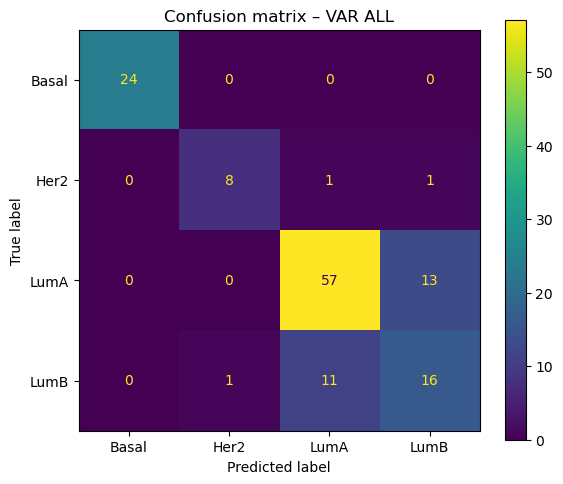


Loading MOFA model: var_intersection from exports_500\mofa_var_Kperview_intersection.hdf5
Factors shape: (401, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[VAR INTERSECTION]
Best params: {'clf__C': 1, 'clf__penalty': 'l1'}
CV balanced accuracy (mean ± std): 0.836 ± 0.057
Test balanced accuracy: 0.781
Test accuracy:          0.815
Test ROC-AUC (OvR, w):  0.911

Classification report:
              precision    recall  f1-score   support

       Basal      1.000     1.000     1.000        12
        Her2      1.000     0.667     0.800         6
        LumA      0.851     0.870     0.860        46
        LumB      0.556     0.588     0.571        17

    accuracy                          0.815        81
   macro avg      0.852     0.781     0.808        81
weighted avg      0.822     0.815     0.816        81



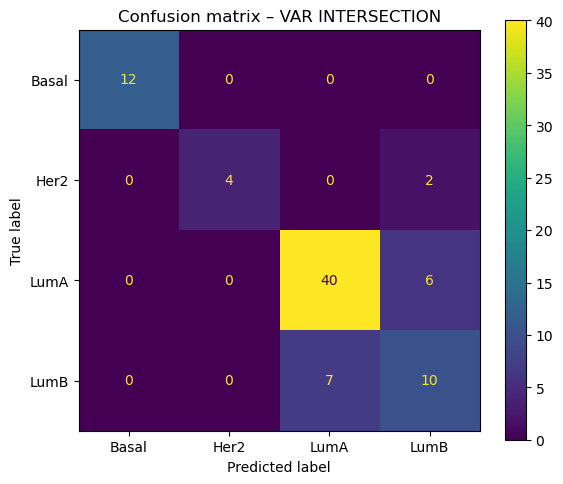


Loading MOFA model: anova_all from exports_500\mofa_anova_Kperview_all.hdf5
Factors shape: (658, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[ANOVA ALL]
Best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
CV balanced accuracy (mean ± std): 0.827 ± 0.030
Test balanced accuracy: 0.874
Test accuracy:          0.864
Test ROC-AUC (OvR, w):  0.950

Classification report:
              precision    recall  f1-score   support

       Basal      0.957     0.917     0.936        24
        Her2      0.900     0.900     0.900        10
        LumA      0.896     0.857     0.876        70
        LumB      0.719     0.821     0.767        28

    accuracy                          0.864       132
   macro avg      0.868     0.874     0.870       132
weighted avg      0.869     0.864     0.866       132



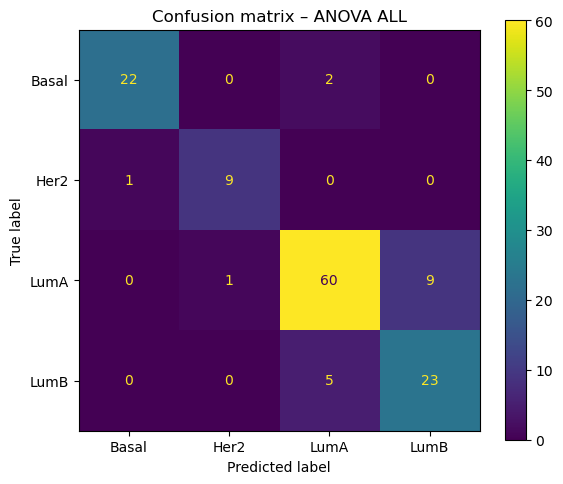


Loading MOFA model: anova_intersection from exports_500\mofa_anova_Kperview_intersection.hdf5
Factors shape: (401, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[ANOVA INTERSECTION]
Best params: {'clf__C': 1, 'clf__penalty': 'l1'}
CV balanced accuracy (mean ± std): 0.878 ± 0.064
Test balanced accuracy: 0.803
Test accuracy:          0.802
Test ROC-AUC (OvR, w):  0.917

Classification report:
              precision    recall  f1-score   support

       Basal      0.923     1.000     0.960        12
        Her2      0.714     0.833     0.769         6
        LumA      0.848     0.848     0.848        46
        LumB      0.600     0.529     0.562        17

    accuracy                          0.802        81
   macro avg      0.771     0.803     0.785        81
weighted avg      0.797     0.802     0.799        81



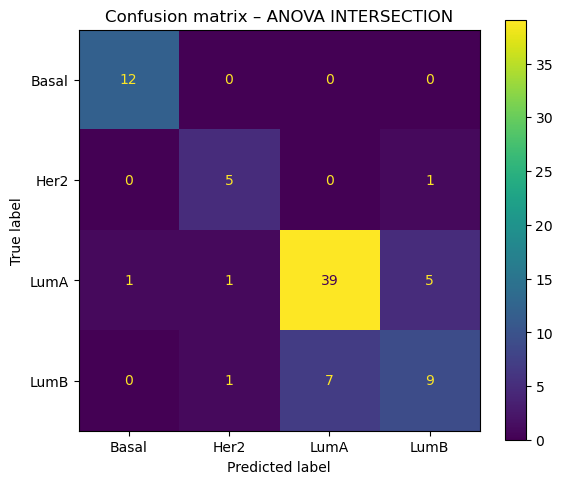

,title,mean_cv_bal_acc,std_cv_bal_acc,test_bal_acc,test_acc,test_roc_auc_ovr
0,VAR ALL,0.819264,0.017516,0.796429,0.795455,0.941860
1,VAR INTERSECTION,0.836473,0.057358,0.781117,0.814815,0.910807
2,ANOVA ALL,0.826870,0.029957,0.873810,0.863636,0.950122
3,ANOVA INTERSECTION,0.878166,0.064123,0.802643,0.802469,0.917288


In [11]:
results = []

for key, path in MODEL_FILES.items():
    print("\n" + "=" * 80)
    print(f"Loading MOFA model: {key} from {path}")
    model = mofa.mofa_model(path)

    # factors as DataFrame
    # index: sample IDs, columns: Factor1,...,FactorK
    factors_df = model.get_factors(df=True)  # docs: df=True -> DataFrame

    print("Factors shape:", factors_df.shape)

    res = run_logreg_on_factors(
        X_factors=factors_df,
        labels_any=pam_any,
        title=key.replace("_", " ").upper(),
        verbose=True,
    )
    results.append(res)

# Summary table
results_df = pd.DataFrame(results)
results_df


## Interpretability - which features drive the factors

In [50]:
# 1) Feature selection: most variable per view (K per view)
filtered_data_var, feat_idx_var = select_top_variable_features_per_view(
    data,
    n_keep_per_view=N_KEEP_PER_VIEW, 
    views=VIEWS,                   
    use="var",
)

# 2) Build MuData for patient_mode="all"

mdata_var_all = build_mdata_from_filtered_views(
    filtered_data=filtered_data_var,
    full_data=data,
    views=VIEWS,
    patient_mode="intersection",  
)

print("mdata_var_intersection:")
print("  n_obs:", mdata_var_all.n_obs)
for mod_key in mdata_var_all.mod:
    print(f"  {mod_key}: {mdata_var_all[mod_key].X.shape}")

# 3) Load the corresponding MOFA model
#     (tag = 'var_Kperview_all' from your training loop)
tag = "var_Kperview_intersection"
model_path = os.path.join(EXPORT_DIR, f"mofa_{tag}.hdf5")
print("\nLoading MOFA model from:", model_path)

model_var_all = mfx.mofa_model(model_path)

# 4) Helper: top-N MOFA features across ALL modalities (mofax version)
def top_mofa_features_global(
    model,
    mdata,
    modalities: list[str] | None = None,
    top_n: int = 20,
    agg: str = "max",
) -> pd.DataFrame:
    """
    Top-N most informative MOFA features across *all* modalities.

    Parameters
    ----------
    model : mofax.mofa_model
        Loaded MOFA model.
    mdata : mu.MuData
        MuData object built from the same filtered views.
    modalities : list of str or None
        Modalities to include (e.g. ["rna", "dna", "rppa"]).
        If None, use mdata.mod keys.
    top_n : int
        Number of features to return in total.
    agg : {"max", "l2"}
        How to aggregate loadings across factors for each feature:
        - "max": max absolute weight over factors
        - "l2" : L2-norm of weights over factors

    Returns
    -------
    DataFrame with columns:
        - modality
        - feature
        - score   (importance score)
    """
    if modalities is None:
        modalities = list(mdata.mod.keys())

    rows = []

    for mod in modalities:
        # weights for THIS modality: (n_features x n_factors)
        W = model.get_weights(mod)

        # feature names for this modality
        feat_names = mdata[mod].var_names

        if agg == "max":
            scores = np.max(np.abs(W), axis=1)
        elif agg == "l2":
            scores = np.linalg.norm(W, axis=1)
        else:
            raise ValueError("agg must be 'max' or 'l2'")

        df_mod = pd.DataFrame(
            {
                "modality": mod,
                "feature": feat_names,
                "score": scores,
            }
        )
        rows.append(df_mod)

    all_feats = pd.concat(rows, ignore_index=True)
    all_feats = all_feats.replace([np.inf, -np.inf], np.nan).dropna(subset=["score"])

    top_global = (
        all_feats.sort_values("score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return top_global

# 5) Compute top 20 features globally (across all views)

modality_keys = list(mdata_var_all.mod.keys())  # usually ['rna', 'dna', 'rppa']
print("\nModalities in mdata:", modality_keys)

top30_global_var_all = top_mofa_features_global(
    model=model_var_all,
    mdata=mdata_var_all,
    modalities=modality_keys,
    top_n=30,
    agg="max",   # or "l2"
)

top30_global_var_all


mRNA: kept 500 / 29995 features (most variable, var)
DNAm: kept 500 / 100000 features (most variable, var)
RPPA: kept 464 / 464 features (most variable, var)
mdata_var_intersection:
  n_obs: 401
  rna: (401, 500)
  dna: (401, 500)
  rppa: (401, 464)

Loading MOFA model from: exports_500\mofa_var_Kperview_intersection.hdf5

Modalities in mdata: ['rna', 'dna', 'rppa']


C:\Users\Petar\anaconda3\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\Petar\anaconda3\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


,modality,feature,score
0,rna,ENSG00000153002.12,1.130651
1,rna,ENSG00000120251.21,1.034453
2,rna,ENSG00000173467.9,0.994721
3,rna,ENSG00000172551.11,0.979640
4,rna,ENSG00000160182.3,0.969279
5,rna,ENSG00000159763.4,0.899906
6,rna,ENSG00000180730.5,0.881496
7,rna,ENSG00000256612.7,0.858985
8,rna,ENSG00000255974.8,0.846296
9,rna,ENSG00000106541.12,0.837553


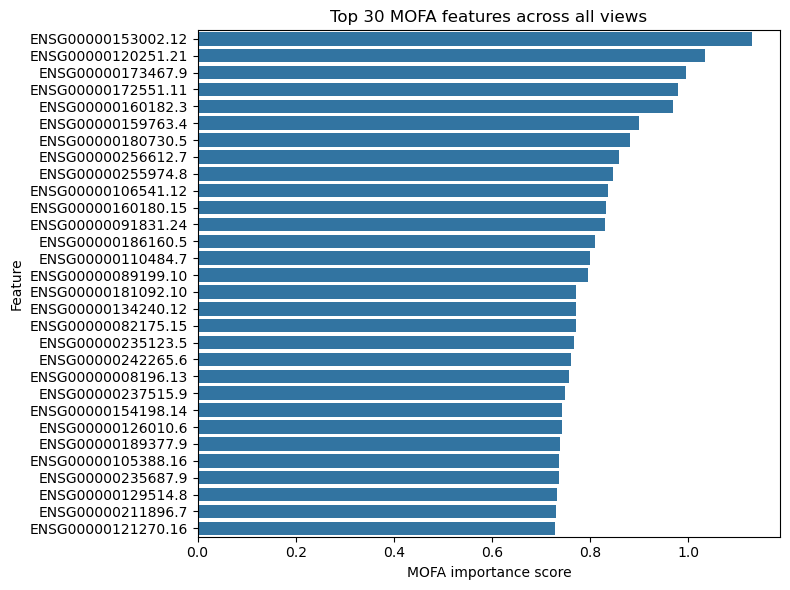

In [51]:
df = top30_global_var_all.copy()
df_sorted = df.sort_values("score", ascending=False)  # biggest first

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=df_sorted,
    x="score",
    y="feature",
    hue="modality",
    dodge=False,
    ax=ax,
)

ax.set_xlabel("MOFA importance score")
ax.set_ylabel("Feature")
ax.set_title("Top 30 MOFA features across all views")
#ax.legend(title="Modality", bbox_to_anchor=(1.05, 1), loc="upper left")
if ax.get_legend() is not None:
    ax.get_legend().remove()

fig.tight_layout()
fig.savefig("top20_mofa_features_global.pdf", dpi=300, bbox_inches="tight")
plt.show()


Modalities: ['rna', 'dna', 'rppa']

=== Top 20 features in modality 'rna' ===


,feature,score
0,ENSG00000153002.12,1.130651
1,ENSG00000120251.21,1.034453
2,ENSG00000173467.9,0.994721
3,ENSG00000172551.11,0.979640
4,ENSG00000160182.3,0.969279
5,ENSG00000159763.4,0.899906
6,ENSG00000180730.5,0.881496
7,ENSG00000256612.7,0.858985
8,ENSG00000255974.8,0.846296
9,ENSG00000106541.12,0.837553


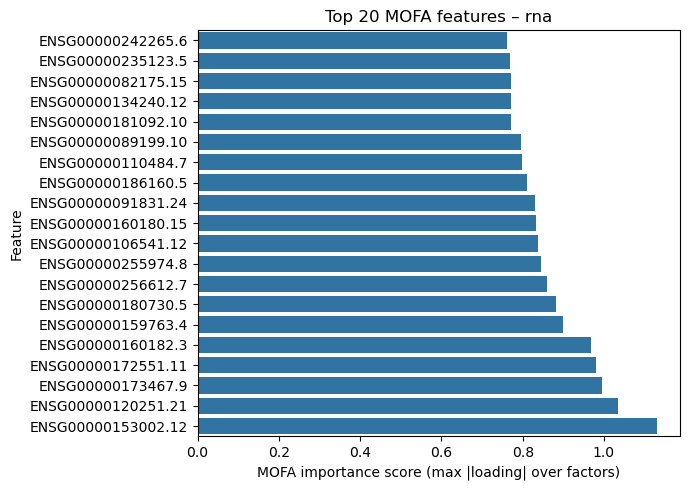


=== Top 20 features in modality 'dna' ===


,feature,score
0,cg14223646,0.124574
1,cg16322121,0.119481
2,cg03904209,0.118373
3,cg02181080,0.117617
4,cg26894484,0.117138
5,cg10842339,0.114477
6,cg23521666,0.110682
7,cg13782274,0.110277
8,cg00794174,0.109468
9,cg04696181,0.108485


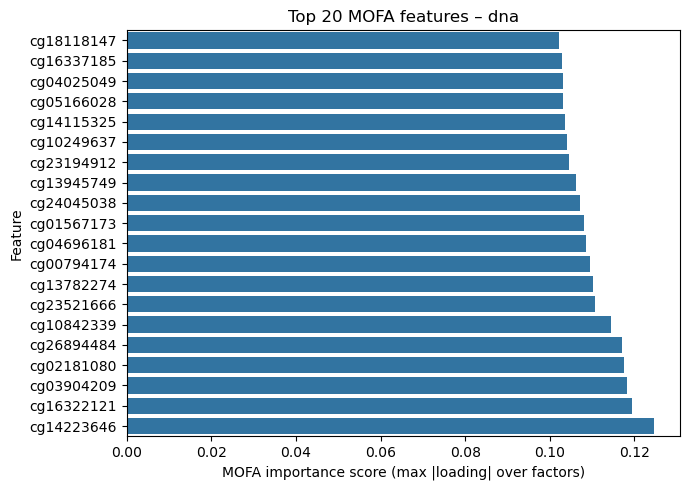


=== Top 20 features in modality 'rppa' ===


,feature,score
0,ERALPHA,0.402827
1,Gli1,0.341580
2,GATA3,0.258691
3,COLLAGENVI,0.252561
4,MAPK_pT202Y204,0.244137
5,CAVEOLIN1,0.241810
6,CYCLINB1,0.228697
7,MYH11,0.223104
8,HSP70,0.219382
9,INPP4B,0.208450


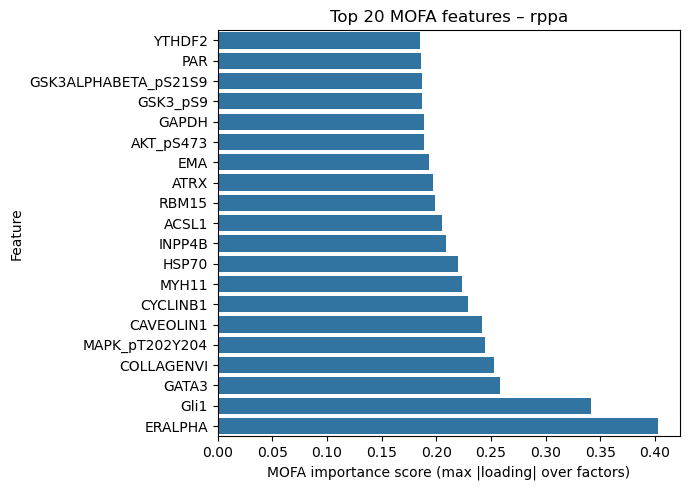

In [52]:
def top_mofa_features_per_view(
    model,
    mdata,
    modality: str,
    top_n: int = 30,
    agg: str = "max",
) -> pd.DataFrame:
    """
    Top-N most informative MOFA features *within one modality*.

    Parameters
    ----------
    model : mofax.mofa_model
    mdata : mu.MuData
    modality : str
        Modality key in mdata (e.g. "rna", "dna", "rppa").
    top_n : int
        Number of features to keep for this modality.
    agg : {"max", "l2"}
        How to aggregate loadings across factors per feature:
        - "max": max absolute loading over factors
        - "l2" : L2 norm over factors

    Returns
    -------
    DataFrame with columns: feature, score.
    """
    W = model.get_weights(modality)         # (n_features x n_factors)
    feat_names = mdata[modality].var_names

    if agg == "max":
        scores = np.max(np.abs(W), axis=1)
    elif agg == "l2":
        scores = np.linalg.norm(W, axis=1)
    else:
        raise ValueError("agg must be 'max' or 'l2'")

    df = pd.DataFrame(
        {"feature": feat_names, "score": scores}
    ).sort_values("score", ascending=False)

    return df.head(top_n).reset_index(drop=True)


# Example: top-20 per view + barplots
modalities = list(mdata_var_all.mod.keys())  # e.g. ['rna', 'dna', 'rppa']
print("Modalities:", modalities)

top_per_view = {}

for mod in modalities:
    print(f"\n=== Top 20 features in modality '{mod}' ===")
    df_top = top_mofa_features_per_view(
        model=model_var_all,
        mdata=mdata_var_all,
        modality=mod,
        top_n=20,
        agg="max",
    )
    top_per_view[mod] = df_top
    display(df_top)  # Jupyter pretty print

    # Barplot
    df_plot = df_top.sort_values("score", ascending=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(
        data=df_plot,
        x="score",
        y="feature",
        ax=ax,
        color="tab:blue",
    )
    ax.set_xlabel("MOFA importance score (max |loading| over factors)")
    ax.set_ylabel("Feature")
    ax.set_title(f"Top 20 MOFA features – {mod}")

    fig.tight_layout()
    fig.savefig(f"top20_mofa_features_{mod}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
